# 01 Make reproducible peaks

Reproducible peaks from merged bioreps are those that overlap peaks form at least two different bioreps. All datasets are filtered with q-value < 1e-5 (Control FDR at 1 in 100k, which is sufficiently stringent given we have less than 100k peaks for every protein).

In [1]:
import bioframe as bf
import pandas as pd
import numpy as np
from pathlib import Path

## Locate peaks files

In [2]:
COND = 'WT_G2'
PROTS_REPS = {'Sororin': (1, 2),
              'RAD21': (1, 2),
              'CTCF': (1, 2, 3)}
REPO_FOLDER = Path('/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/')

In [4]:
peaks_data = dict()
for prot, reps in PROTS_REPS.items():
    peaks_data[prot] = dict()
    
    prot_folder = REPO_FOLDER / prot / COND
    tag_merged = f"{prot}_{COND}"
    path_merged = prot_folder / f"{tag_merged}.peaks_noblacklist.narrowPeak"
    peaks_merged = bf.read_table(path_merged, schema='narrowPeak')
    peaks_data[prot]['merged'] = peaks_merged
    peaks_data[prot]['reps'] = dict()

    for rep in reps:
        rep_folder = prot_folder / f"bio_rep{rep}"
        tag_rep = f"{prot}_{COND}_BR{rep}"
        path_rep = rep_folder / f"{tag_rep}.peaks_noblacklist.narrowPeak"
        peaks_rep = bf.read_table(path_rep, schema='narrowPeak')
        peaks_data[prot]['reps'][rep] = peaks_rep

In [7]:
peaks_data['Sororin']['merged'].head()

,chrom,start,end,name,score,strand,fc,-log10p,-log10q,relSummit
0,chr1,805073,805584,chip_peak_4,292,.,5.33785,32.06060,29.28230,205
1,chr1,873489,873772,chip_peak_5,44,.,2.49562,6.60352,4.40350,187
2,chr1,919513,919969,chip_peak_6,95,.,3.22745,11.93990,9.54084,221
3,chr1,994722,995502,chip_peak_7,52,.,2.63426,7.50752,5.26338,101
4,chr1,998956,999882,chip_peak_8,628,.,7.27009,66.05540,62.87300,426


## Filter peaks and annotate overlaps

In [36]:
def filter_peaks(df, QVAL_THRESH=5, FC_THRESH=0):
    return df.query(f"`-log10q` >= {QVAL_THRESH}").query(f'fc >= {FC_THRESH}').reset_index(drop=True)

In [9]:
UNIQUE_PEAK_COLS = ['chrom', 'start', 'end']
SUPPORT_THRESHOLD = 2

In [37]:
filtered_peaks = dict()
for prot, data in peaks_data.items():
    merged_peaks = filter_peaks(data['merged'])
    for rep, rep_peaks in data['reps'].items():
        rep_peaks = filter_peaks(rep_peaks)
        overlap_df = bf.overlap(merged_peaks[UNIQUE_PEAK_COLS],
                                rep_peaks[UNIQUE_PEAK_COLS],
                                how='left')
        overlap_col = f'overlap_{rep}'
        overlap_df[overlap_col] = (~overlap_df[UNIQUE_PEAK_COLS[0] + '_'].isna())
        overlap_status = overlap_df.groupby(UNIQUE_PEAK_COLS)[overlap_col].any().reset_index()
        merged_peaks = pd.merge(merged_peaks, overlap_status, on=UNIQUE_PEAK_COLS)

    overlap_cols = [col for col in merged_peaks.columns if col.startswith('overlap')]
    merged_peaks['overlap_count'] = merged_peaks[overlap_cols].astype('int').sum(axis=1)
    merged_peaks['reproducible'] = merged_peaks['overlap_count'] >= SUPPORT_THRESHOLD
    filtered_peaks[prot] = merged_peaks

In [38]:
filtered_peaks['Sororin'].head()

,chrom,start,end,name,score,strand,fc,-log10p,-log10q,relSummit,overlap_1,overlap_2,overlap_count,reproducible
0,chr1,805073,805584,chip_peak_4,292,.,5.33785,32.06060,29.28230,205,True,True,2,True
1,chr1,919513,919969,chip_peak_6,95,.,3.22745,11.93990,9.54084,221,False,True,1,False
2,chr1,994722,995502,chip_peak_7,52,.,2.63426,7.50752,5.26338,101,False,False,0,False
3,chr1,998956,999882,chip_peak_8,628,.,7.27009,66.05540,62.87300,426,True,True,2,True
4,chr1,1004569,1004844,chip_peak_9,61,.,2.77291,8.45529,6.17093,128,False,True,1,False


In [39]:
print('protein', 'N_reprod_peaks', sep='\t')
for prot, df in filtered_peaks.items():
    print(prot, df.query('reproducible').shape[0], sep='\t')

protein	N_reprod_peaks
Sororin	24138
RAD21	60002
CTCF	61387


## Save reproducible peaks to files

In [50]:
proper_cols = bf.io.SCHEMAS['narrowPeak']

In [51]:
for prot, df in filtered_peaks.items():
    path = f'./{prot}_{COND}.reprod_peaks.narrowPeak'
    df.query('reproducible').reset_index(drop=True)[proper_cols].to_csv(path, header=False, index=False, sep='\t')

# REMOVE BEFORE PUBLICATION

## QC and stuff

In [42]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from itertools import combinations

0.544 24138


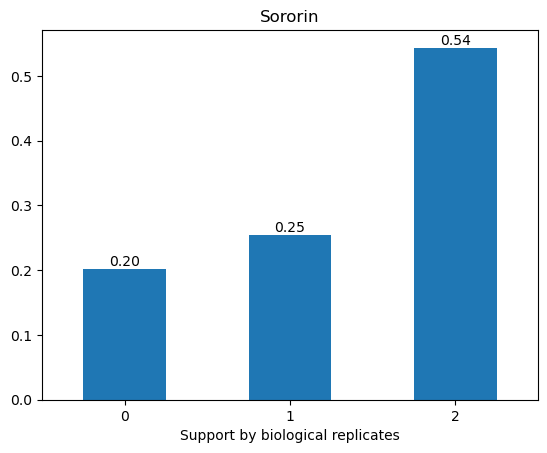

0.558 60002


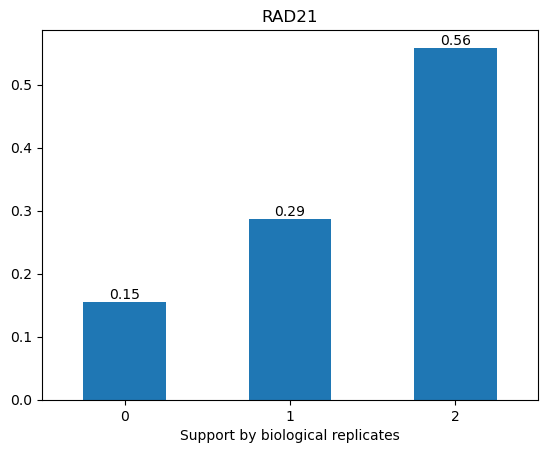

0.683 61387


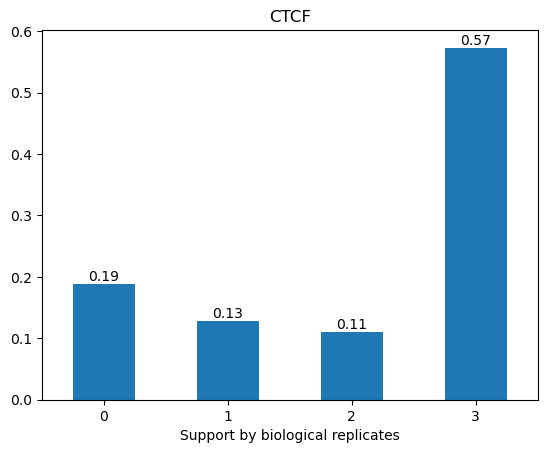

In [43]:
for protein, peaks in filtered_peaks.items():
    print('%.3f' % peaks['reproducible'].mean(), peaks['reproducible'].sum())
    g = peaks['overlap_count'].value_counts(normalize=True).sort_index().plot(kind='bar')
    for container in g.containers:
        plt.bar_label(container, fmt='%.2f')
    plt.xticks(rotation=0)
    plt.title(protein)
    plt.xlabel('Support by biological replicates')
    plt.show()

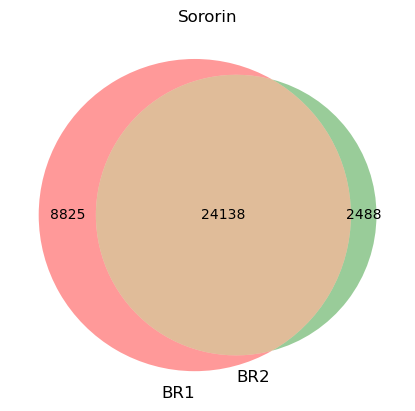

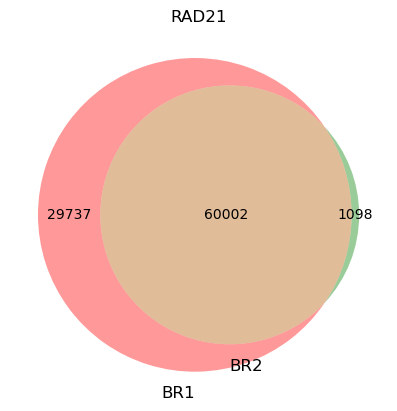

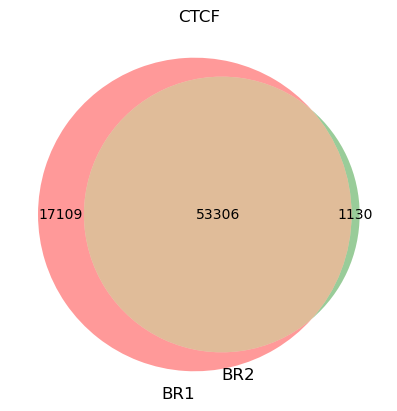

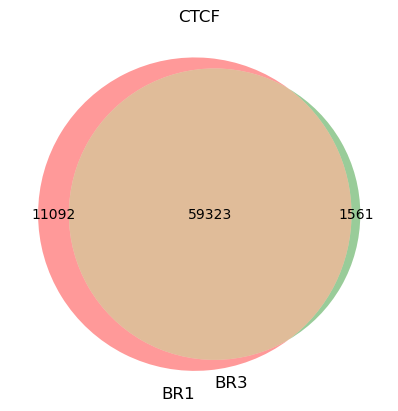

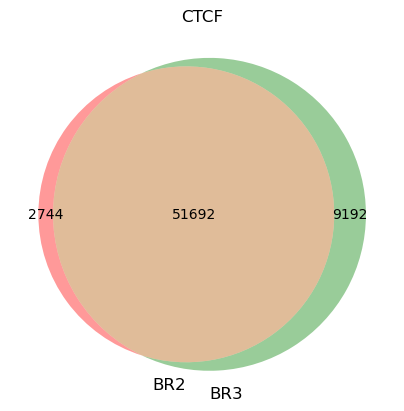

In [44]:
for protein, df in filtered_peaks.items():
    select_cols = [col for col in df.columns if col.startswith('overlap_') and col != 'overlap_count']
    
    for col1, col2 in combinations(select_cols, 2):
        rep1 = col1[-1]
        rep2 = col2[-1]
        venn_df = df[[col1, col2]].value_counts().reset_index()
        
        overlap_1 = venn_df[col1].astype('int').astype('str')
        overlap_2 = venn_df[col2].astype('int').astype('str')
        venn_df['overlap_combined_code'] = overlap_1 + overlap_2
        
        overlap_dict = venn_df[['overlap_combined_code', 0]].set_index('overlap_combined_code').squeeze().to_dict()
        del overlap_dict['00']

        fig, ax = plt.subplots(1, 1)
        venn2(overlap_dict, (f'BR{rep1}', f'BR{rep2}'), ax=ax)
        ax.set_title(protein)
        plt.show()

It actually looks fine. Probably, differences in sequencing depth affect reproducibility.

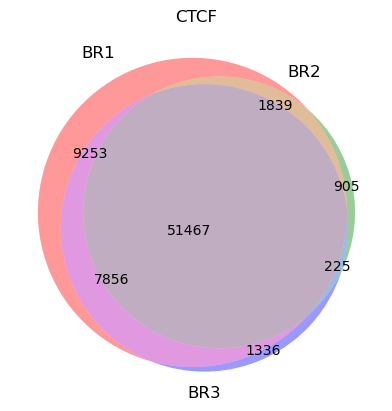

In [45]:
for protein in ('CTCF',):
    df = filtered_peaks[protein]
    select_cols = [col for col in df.columns if col.startswith('overlap_') and col != 'overlap_count']
    venn_df = df[select_cols].value_counts().reset_index()
    venn_df['overlap_combined_code'] = venn_df[select_cols].astype('int').astype('str').apply(lambda row: ''.join(row.values), axis=1)
    overlap_dict = venn_df[['overlap_combined_code', 0]].set_index('overlap_combined_code').squeeze().to_dict()
    del overlap_dict['000']
    fig, ax = plt.subplots(1, 1)
    venn3(overlap_dict, ('BR1', 'BR2', 'BR3'), ax=ax)
    ax.set_title(protein)
    plt.show()    

Somehow CTCF peaks are more reproducible now than they used to be.

## Compare reproducible peaks across proteins

In [46]:
reprod_peaks = {protein: peaks.query('reproducible').reset_index(drop=True)
                for protein, peaks in filtered_peaks.items()}

### RAD21 vs Sororin

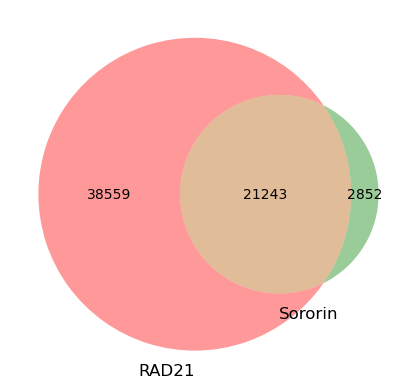

In [47]:
reference_2 = bf.merge(pd.concat((reprod_peaks['RAD21'], reprod_peaks['Sororin']), ignore_index=True))
rad21_idx = set(bf.overlap(reference_2, reprod_peaks['RAD21'], how='inner', return_input=False, return_index=True)['index'].to_list())
sor_idx = set(bf.overlap(reference_2, reprod_peaks['Sororin'], how='inner', return_input=False, return_index=True)['index'].to_list())
venn2((rad21_idx, sor_idx), ('RAD21', 'Sororin'))

### Sororin vs CTCF

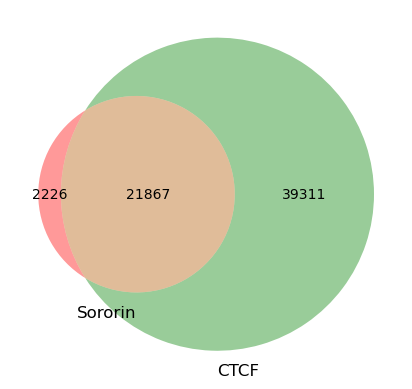

In [48]:
reference_2 = bf.merge(pd.concat((reprod_peaks['Sororin'], reprod_peaks['CTCF']), ignore_index=True))
sor_idx = set(bf.overlap(reference_2, reprod_peaks['Sororin'], how='inner', return_input=False, return_index=True)['index'].to_list())
ctcf_idx = set(bf.overlap(reference_2, reprod_peaks['CTCF'], how='inner', return_input=False, return_index=True)['index'].to_list())
venn2((sor_idx, ctcf_idx), ('Sororin', 'CTCF'))

### 3-way

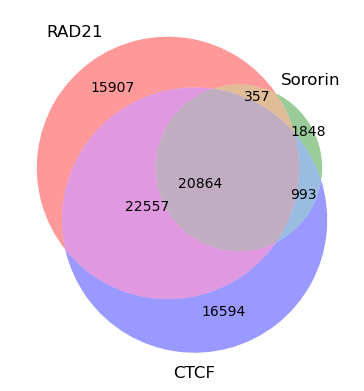

In [49]:
reference_3 = bf.merge(pd.concat((reprod_peaks['RAD21'], reprod_peaks['Sororin'], reprod_peaks['CTCF']), ignore_index=True))
rad21_idx = set(bf.overlap(reference_3, reprod_peaks['RAD21'], how='inner', return_input=False, return_index=True)['index'].to_list())
sor_idx = set(bf.overlap(reference_3, reprod_peaks['Sororin'], how='inner', return_input=False, return_index=True)['index'].to_list())
ctcf_idx = set(bf.overlap(reference_3, reprod_peaks['CTCF'], how='inner', return_input=False, return_index=True)['index'].to_list())
venn3((rad21_idx, sor_idx, ctcf_idx), ('RAD21', 'Sororin', 'CTCF'))